In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

In [13]:
# --- 1. Data Loading and Preprocessing ---
# We read the 'data' sheet as specified in the assignment

df = pd.read_excel('/content/EastWestAirlines.xlsx', sheet_name='data')


In [14]:
# Handle the ID column if it exists (dropping it for clustering)
if 'ID#' in df.columns:
    df = df.drop(['ID#'], axis=1)

In [15]:
# Removing duplicates to ensure cluster quality
df = df.drop_duplicates()

In [16]:
# Scaling the features
# Necessary because 'Balance' has a much larger range than 'Award?' or 'cc_miles'
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [17]:
# --- 2. Exploratory Data Analysis (EDA) ---
print("Statistical Summary:")
print(df.describe().T)

Statistical Summary:
                    count          mean            std  min       25%  \
Balance            3998.0  73619.486993  100781.726667  0.0  18534.25   
Qual_miles         3998.0    144.150575     773.757220  0.0      0.00   
cc1_miles          3998.0      2.059780       1.376990  1.0      1.00   
cc2_miles          3998.0      1.014507       0.147669  1.0      1.00   
cc3_miles          3998.0      1.012256       0.195265  1.0      1.00   
Bonus_miles        3998.0  17149.134567   24152.465996  0.0   1250.00   
Bonus_trans        3998.0     11.604802       9.603258  0.0      3.00   
Flight_miles_12mo  3998.0    460.170835    1400.365407  0.0      0.00   
Flight_trans_12    3998.0      1.373937       3.793585  0.0      0.00   
Days_since_enroll  3998.0   4119.190095    2065.007629  2.0   2331.25   
Award?             3998.0      0.370435       0.482982  0.0      0.00   

                       50%       75%        max  
Balance            43138.0  92405.00  1704838.0  
Qu

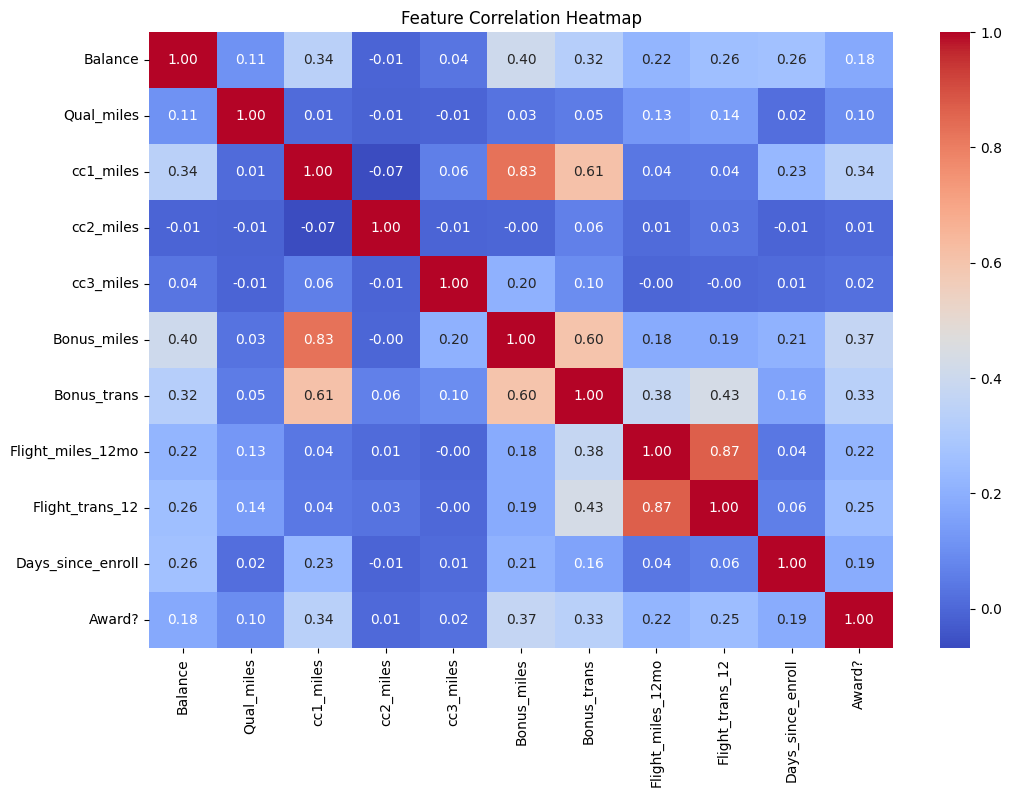

In [18]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

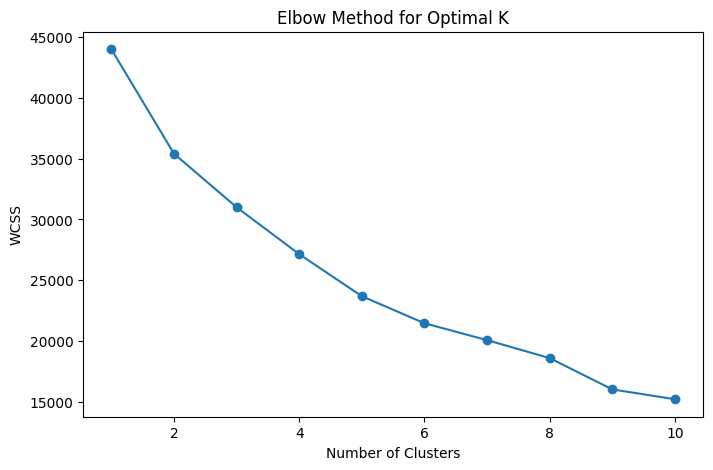

In [19]:
# --- 3. K-Means Clustering ---
# Elbow Method to find optimal K
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [20]:
# Building final K-Means model with K=5
kmeans_model = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['KMeans_Cluster'] = kmeans_model.fit_predict(df_scaled)

In [21]:
# Evaluation
k_score = silhouette_score(df_scaled, df['KMeans_Cluster'])
print(f"K-Means Silhouette Score: {k_score:.4f}")

K-Means Silhouette Score: 0.3231


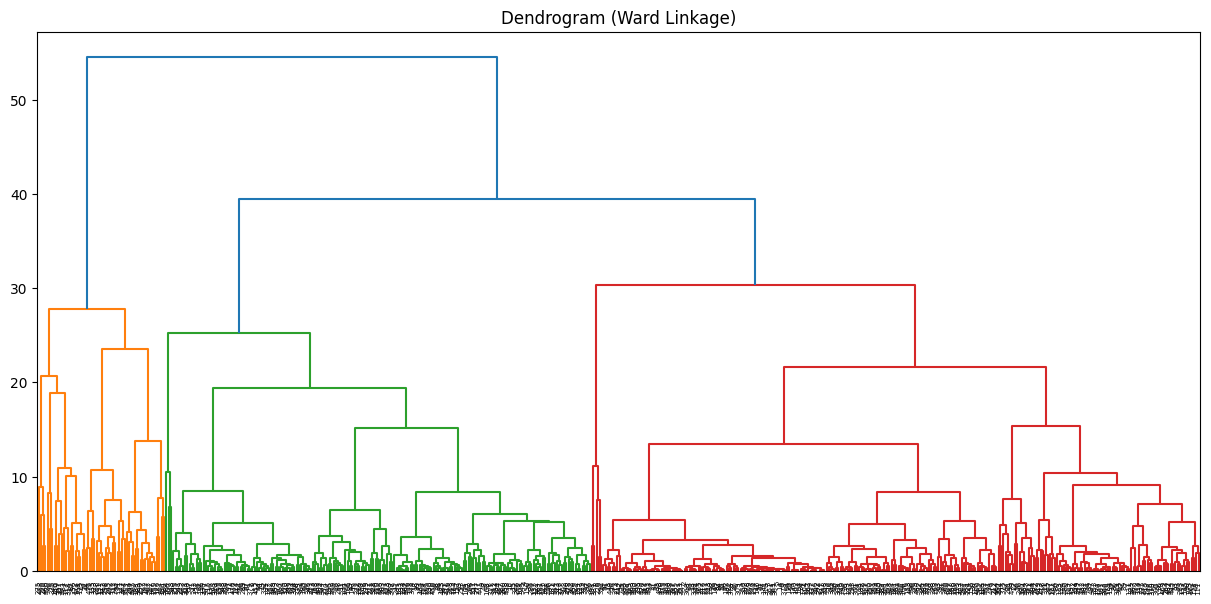

In [22]:
# --- 4. Hierarchical Clustering ---
plt.figure(figsize=(15, 7))
plt.title("Dendrogram (Ward Linkage)")
# Sample for visual clarity
dendrogram = sch.dendrogram(sch.linkage(df_scaled[:500], method='ward'))
plt.show()

hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['Hierarchical_Cluster'] = hc.fit_predict(df_scaled)

In [23]:
# --- 5. DBSCAN Clustering ---
# Epsilon and min_samples tuned for this normalized dataset
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df_scaled)

# Evaluation (ignoring noise points for the score if necessary)
db_score = silhouette_score(df_scaled, df['DBSCAN_Cluster'])
print(f"DBSCAN Silhouette Score: {db_score:.4f}")

DBSCAN Silhouette Score: 0.2537


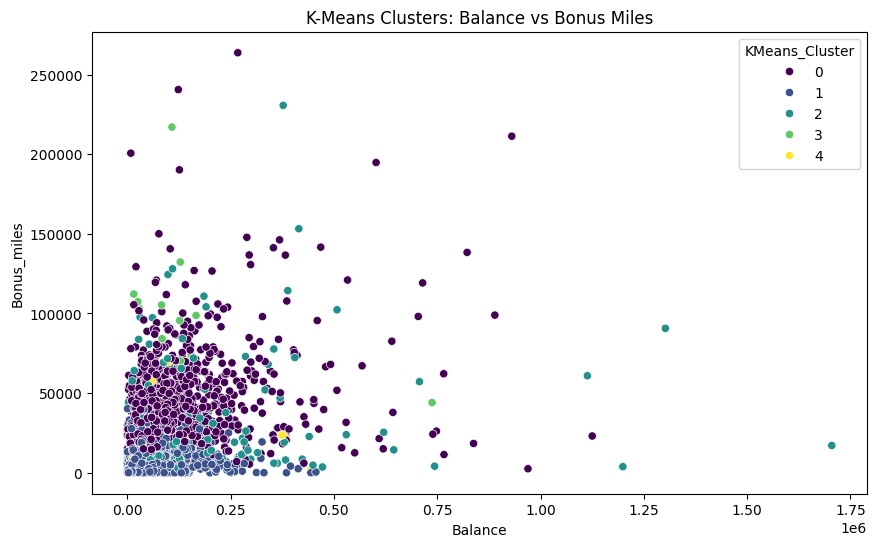

In [24]:
# --- 6. Visualization ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Balance', y='Bonus_miles', hue='KMeans_Cluster', data=df, palette='viridis')
plt.title('K-Means Clusters: Balance vs Bonus Miles')
plt.show()

In [25]:
# Final Interpretation Summary
print("\nCluster Characteristics (K-Means Means):")
print(df.groupby('KMeans_Cluster').mean())


Cluster Characteristics (K-Means Means):
                      Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Cluster                                                               
0               116600.339342  154.392633   3.700627   1.000000   1.001567   
1                43756.981200   99.112800   1.221200   1.000000   1.000400   
2               189778.103659  788.689024   2.189024   1.000000   1.000000   
3               138061.400000   78.800000   3.466667   1.000000   4.066667   
4                68876.581395   23.255814   1.139535   2.348837   1.000000   

                 Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Cluster                                                                  
0               39131.264107    18.719436         333.050157         0.993730   
1                4572.811200     6.794000         198.298000         0.616400   
2               31452.060976    26.524390        5404.835366        15.640244   
3     